## Text classification on LeMonde2003 Dataset

In this notebook, we 
apply classification algorithms to newspaper articles published in 2003 in *Le Monde*. 

The data are here : https://cloud.teklia.com/index.php/s/isNwnwA7a7AWst6/download/LeMonde2003_9classes.csv.gz

Download it into the data directory : 

```
wget https://cloud.teklia.com/index.php/s/isNwnwA7a7AWst6/download/LeMonde2003_9classes.csv.gz
```

Or you can download the file directly from the URL in pandas with `pd.read_csv(url)`.`

These articles concern different subjects but we will consider only articles related to the following subjects : entreprises (ENT), international (INT), arts (ART), société (SOC), France (FRA), sports (SPO), livres (LIV), télévision (TEL) and the font page articles (UNE).


> * Load the CSV file `LeMonde2003_9classes.csv.gz` containing the articles using pandas [pd.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). How many articles do you have ? 
> * Plot the frequency histogram of the categories using seaborn [countplot](https://seaborn.pydata.org/tutorial/categorical.html) : `sns.countplot(data=df,y='category')`
> * Display the text of some of the article with the corresponding class using pandas [sample](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html)
> * Using the [WordCloud library](https://amueller.github.io/word_cloud/index.html), display a word cloud for the most frequent classes. You can remove the stop words using the `stopwords` option, using the list of stop words in French in `data/stop_word_fr.txt` or from the URL https://cloud.teklia.com/index.php/s/3mwZfSre4PmJcdb/download/stop_word_fr.txt



In [1]:
import pandas as pd

# load dataframe from CSV file
file = "/home/onyxia/work/nlp-lab-text-classification/data/LeMonde2003_9classes.csv"
df = pd.read_csv(file)
print(f"The dataframe contains {df.shape[0]} articles.")

The dataframe contains 30165 articles.


<Axes: xlabel='count', ylabel='category'>

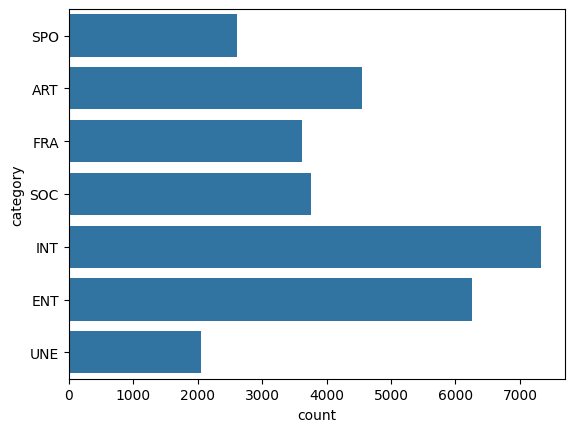

In [2]:
import seaborn as sns
%matplotlib inline

# Plot the statistics of category
sns.countplot(data=df, y='category')

In [3]:
# Print examples of the articles
pd.set_option('display.max_colwidth', None)
# YOUR CODE HERE
pd.set_option('display.max_colwidth', None)

print("Example of articles :")
pd.DataFrame.sample(df, n=1)

Example of articles :


,text,category
9900,"la société de lanceurs de satellites a enregistré une perte opérationnelle autour de 50 à 60 millions d'euros en 2002 pour un chiffre d'affaires de 1,3 milliard d'euros avec 12 lancements effectués a indiqué son directeur général jean-yves le gall dans un entretien aux echos lundi",ENT


Category: ENT


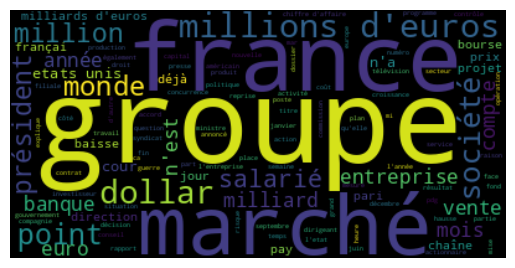

Category: INT


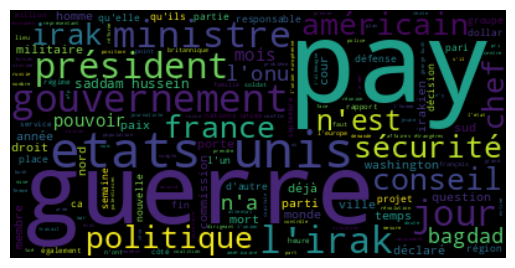

Category: ART


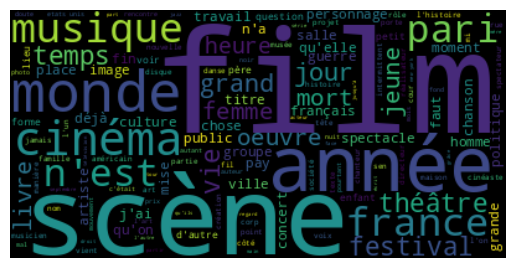

Category: SOC


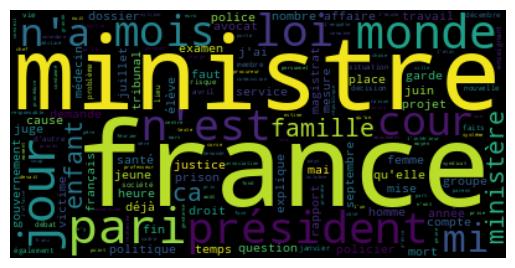

Category: FRA


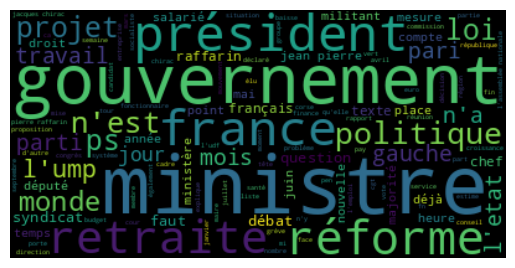

In [4]:
from wordcloud import WordCloud
# Display one wordcloud for each of the most frequent classes

from wordcloud import WordCloud
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]
import matplotlib.pyplot as plt

for cat in ['ENT', 'INT', 'ART', 'SOC', 'FRA']:
    text = df[df.category == cat].iloc[:, 0].str.cat(sep=' ')
    wordcloud = WordCloud(stopwords=STOPWORDS).generate(text)
    print(f"Category: {cat}")
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

## Bag-of-word representation

In order to apply machine learning algorithms to text, documents must be transformed into vectors. The most simple and standard way to transform a document into a vector is the *bag-of-word* encoding.

The idea is very simple : 

1. define the set of all the possible words that can appear in a document; denote its size by `max_features`.
2. for each document,  encode it with a vector of size `max_features`, with the value of the ith component of the vector equal to the number of time the ith word appears in the document.

See [the wikipedia article on Bag-of-word](https://en.wikipedia.org/wiki/Bag-of-words_model) for an example.

Scikit-learn proposes different methods to encode text into vectors : [CountVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) and [TfidfTransformer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html).

The encoder must first be trained on the train set and applied to the different sets, for example with the 200  words : 

	from sklearn.feature_extraction.text import CountVectorizer
	vectorizer = CountVectorizer(max_features=200)
    vectorizer.fit(X_train)
    X_train_counts = vectorizer.transform(X_train)
    X_test_counts = vectorizer.transform(X_test)
        
**Question**:

> * Split the dataset LeMonde2003 into train set (80%), dev set (10%)  and test set (10%) using scikit-learn [train_test_split](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
> * For each set, transform the text of the articles into vectors using the `CountVectorizer`, considering the 1000 most frequent words. 
> * Train a naive bayes classifier on the data. 
> * Evaluate the classification accuracy on the train, dev and test sets using the [score](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB.score) method. 

> ***Important*** : the test set must not be used during the training phase, and learning the vector representation of the words is part of the training. The dev set should be an evaluation of the test set.



In [5]:
from sklearn.model_selection import train_test_split

# Split the data into train, dev, and test sets
df_train, df_test = train_test_split(df, train_size=0.8, test_size=0.2, random_state=42)
df_dev, df_test = train_test_split(df_test, train_size=0.5, test_size=0.5, random_state=42)

# Separate features and target variables for each set
X_train, y_train = df_train.iloc[:, 0], df_train.iloc[:, 1]
X_dev, y_dev = df_dev.iloc[:, 0], df_dev.iloc[:, 1]
X_test, y_test = df_test.iloc[:, 0], df_test.iloc[:, 1]

# Print the size of each set
print(f"Size of the train set: {X_train.shape[0]}.")
print(f"Size of the dev set: {X_dev.shape[0]}.")
print(f"Size of the test set: {X_test.shape[0]}.")

Size of the train set: 24132.
Size of the dev set: 3016.
Size of the test set: 3017.


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
# create the vectorizer object
vectorizer = CountVectorizer(max_features=1000)

# fit on train data
vectorizer.fit(X_train)

# apply it on train and dev data
X_train_counts = vectorizer.transform(X_train)
X_dev_counts = vectorizer.transform(X_dev)
X_test_counts = vectorizer.transform(X_test)

In [11]:
from sklearn.naive_bayes import MultinomialNB
# train a Naive Bayes classifier
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)

# Évaluer le modèle
print("Précision sur l'ensemble d'entraînement :", clf.score(X_train_counts, y_train))
print("Précision sur l'ensemble de validation :", clf.score(X_dev_counts, y_dev))
print("Précision sur l'ensemble de test :", clf.score(X_test_counts, y_test))

Précision sur l'ensemble d'entraînement : 0.7285347256754516
Précision sur l'ensemble de validation : 0.7141909814323607
Précision sur l'ensemble de test : 0.7305270135896585


## TF-IDF representation

The `CountVectorizer` encodes the text using the raw frequencies of the words. However, words that are very frequent and appear in all the documents will have a strong weight whereas they are not discriminative. The *Term-Frequency Inverse-Document-Frequency* weighting scheme take into accound the number of documents in which a given word occurs. A word that appear in many document will have less weight. See [the wikipedia page](https://en.wikipedia.org/wiki/Tf%E2%80%93idf) for more details.

With scikit-learn, the `TfidfTransformer` is applied after the `CountVectorizer` :

	from sklearn.feature_extraction.text import TfidfTransformer
	tf_transformer = TfidfTransformer().fit(X_train_counts)
 	X_train_tf = tf_transformer.transform(X_train_counts)
	X_test_tf = tf_transformer.transform(X_test_counts)
	
**Question**:

> * Use the TF-IDF representation to train a Multinomial Naive Bayes classifier. Report your best test error rate and the error rates for all the configurations tested.

In [9]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_dev_tfidf = tfidf_transformer.transform(X_dev_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

best_clf = None
best_test_error = float("inf")
best_alpha = None

alphas = [0.01, 0.1, 1, 2]

for alpha in alphas:
    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train_tfidf, y_train)

    train_err = 1 - clf.score(X_train_tfidf, y_train)
    dev_err = 1 - clf.score(X_dev_tfidf, y_dev)
    test_err = 1 - clf.score(X_test_tfidf, y_test)

    print(f"Alpha={alpha}: Train error={train_err:.4f}, Dev error={dev_err:.4f}, Test error={test_err:.4f}")

    if test_err < best_test_error:
        best_test_error = test_err
        best_alpha = alpha
        best_clf = clf

print(f"\nBest test error: {best_test_error:.4f} with alpha={best_alpha}")

Alpha=0.01: Train error=0.2530, Dev error=0.2649, Test error=0.2526
Alpha=0.1: Train error=0.2534, Dev error=0.2653, Test error=0.2526
Alpha=1: Train error=0.2561, Dev error=0.2686, Test error=0.2542
Alpha=2: Train error=0.2597, Dev error=0.2696, Test error=0.2552

Best test error: 0.2526 with alpha=0.01


## Error analysis

The classification error rate give an evaluation of the performance for all the classes. But since the classes are not equally distributed, they may not be equally well modelized. In order to get a better idea of the performance of the classifier, detailed metrics must be used : 

* [metrics.classification_report](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) provides a detailed analysis per class : the precision (amongst all the example classified as class X, how many are really from the classX) and the recall (amongst all the example that are from the class X, how many are classified as class X) and the F-Score which is as a weighted harmonic mean of the precision and recall.
* [metrics.confusion_matrix](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) which give the confusions between the classes. It can be displayed in color with [plot_confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html#sklearn.metrics.plot_confusion_matrix).

**Question**:

> * Report the `classification_report` for your  classifier. Which classes have the best scores ? Why ?
> * Report the `confusion_matrix` for your  classifier. Which classes are the most confused ? Why ?


Classification report on the test set:

              precision    recall  f1-score   support

         ART       0.75      0.86      0.80       466
         ENT       0.76      0.85      0.80       598
         FRA       0.66      0.66      0.66       357
         INT       0.75      0.90      0.82       750
         SOC       0.68      0.62      0.65       364
         SPO       0.95      0.76      0.84       278
         UNE       0.00      0.00      0.00       204

    accuracy                           0.75      3017
   macro avg       0.65      0.66      0.65      3017
weighted avg       0.70      0.75      0.72      3017

Confusion matrix on the test set:

[[400  23   9  21  10   1   2]
 [ 14 511  14  47  10   2   0]
 [ 13  30 236  30  46   1   1]
 [ 13  31  15 673  18   0   0]
 [ 34  26  47  31 225   1   0]
 [ 11  27   3  18   9 210   0]
 [ 45  24  32  81  15   7   0]]


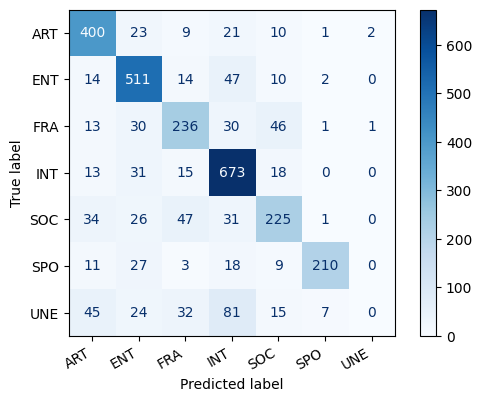

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = best_clf.predict(X_test_tfidf)
print("Classification report on the test set:\n")
print(classification_report(y_test, y_pred))

print("Confusion matrix on the test set:\n")
print(confusion_matrix(y_test, y_pred))

# Optional: visualize the confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
disp.figure_.autofmt_xdate()  # Optional: rotate x-axis labels if needed

## Data re-configuration
After the error analysis, we came to the conclusion that one of the class can not be distinguised from the others. There is no use trying to solve an impossible problem.

**Questions**:

> * Remove the class `UNE` from the original dataset and merge the semantically close classes 'FRANCE' and 'SOCIETE'
> * Plot the class statitics with seaborn
> * Create new splits
> * Retrain a NaiveBayes classifier using [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) with the 1000 most frequent words.

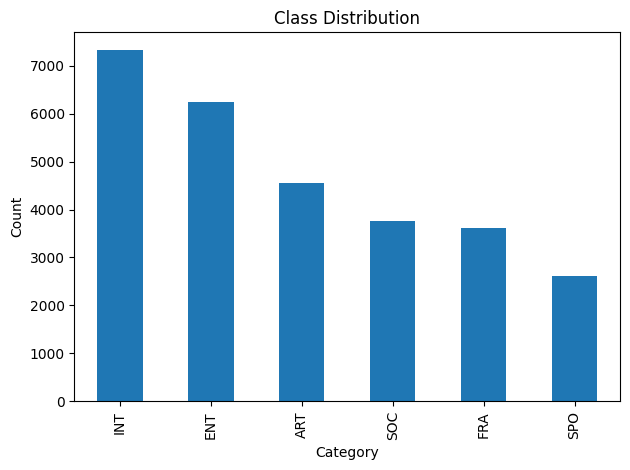

Train size: 22488
Test size: 5622
Accuracy: 0.7912

Classification report:

              precision    recall  f1-score   support

         ART       0.80      0.87      0.83       917
         ENT       0.78      0.84      0.81      1251
         FRA       0.70      0.68      0.69       730
         INT       0.83      0.88      0.85      1515
         SOC       0.70      0.59      0.64       726
         SPO       0.97      0.71      0.82       483

    accuracy                           0.79      5622
   macro avg       0.80      0.76      0.77      5622
weighted avg       0.79      0.79      0.79      5622

Confusion matrix:

[[ 799   41   22   40   11    4]
 [  44 1054   40   85   24    4]
 [  22   82  495   44   87    0]
 [  40   74   31 1327   42    1]
 [  50   57  110   79  430    0]
 [  48   41    9   25   17  343]]


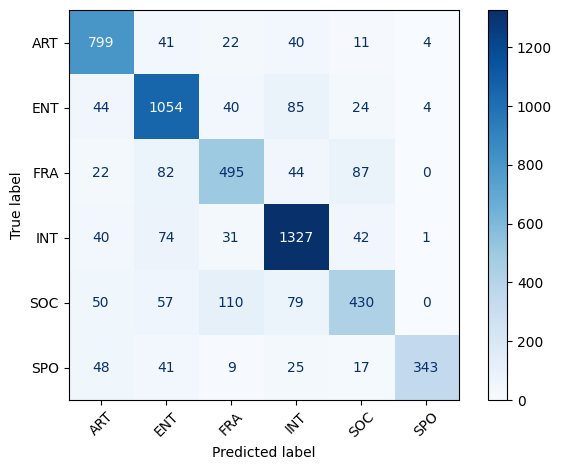

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# Filter out the UNE class
df = df[df['category'] != 'UNE']

# Plot the statistics of classes
df['category'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Make the splits and print the sizes for checking
X = df['text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# Apply TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train MultinomialNB
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# Print accuracy
y_pred = clf.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Print confusion matrix
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

print("Confusion matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.tight_layout()
plt.show()


## What about the LLMs?

**You must write the answer to this question in a notebook hosted in your github account and give access to your supervisor.**

LLMs are reputed to have revolutionised automatic language processing. Since the introduction of BERT-type models, all language processing applications have been based on LLMs, of varying degrees of sophistication and size. These models are trained on multiple tasks and are therefore capable of performing new tasks without learning, simply from a prompt. This is known as "zero-shot learning" because there is no learning phase as such. We are going to test these models on our classification task.

Huggingface is a Franco-American company that develops tools for building applications based on Deep Learning. In particular, it hosts the huggingface.co portal, which contains numerous Deep Learning models. These models can be used very easily thanks to the [Transformer] library (https://huggingface.co/docs/transformers/quicktour) developed by HuggingFace.

Using a transform model in zero-shot learning with HuggingFace is very simple: [see documentation](https://huggingface.co/tasks/zero-shot-classification)

However, you need to choose a suitable model from the list of models compatible with Zero-Shot classification. HuggingFace offers [numerous models](https://huggingface.co/models?pipeline_tag=zero-shot-classification). 

The classes proposed to the model must also provide sufficient semantic information for the model to understand them.

**Question**:

* Write a code to classify an example of text from an article in Le Monde using a model transformed using zero-sot learning with the HuggingFace library.
* choose a model and explain your choice
* choose a formulation for the classes to be predicted
* show that the model predicts a class for the text of the article (correct or incorrect, analyse the results)
* evaluate the performance of your model on 100 articles (a test set).
* note model sizes, processing times and classification results


Notes :
* make sure that you use the correct Tokenizer when using a model 
* start testing with a small number of articles and the first 100's of characters for faster experiments.

In [14]:
from transformers import pipeline

/home/onyxia/work/nlp-lab-text-classification/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
!pip install hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 MB 89.8 MB/s eta 0:00:00:00:0100:01


In [20]:
from transformers import pipeline
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")


Device set to use cpu


In [ ]:
sequence_to_classify = "one day I will see the world"
candidate_labels = ['travel', 'cooking', 'dancing']
classifier(sequence_to_classify, candidate_labels)


{'sequence': 'one day I will see the world',
 'labels': ['travel', 'dancing', 'cooking'],
 'scores': [0.9938651323318481, 0.003273791866376996, 0.0028610299341380596]}

In [33]:
df['category'].unique()

array(['SPO', 'ART', 'FRA', 'SOC', 'INT', 'ENT'], dtype=object)

In [34]:
# Required imports
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import accuracy_score, classification_report

# Use a model suitable for French
model_name = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"

# Create tokenizer and model manually
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Initialize the pipeline with the model and tokenizer
classifier = pipeline("zero-shot-classification", model=model, tokenizer=tokenizer)

# Define correct categories and their full descriptions
category_mapping = {
    "ENT": "Entreprises et économie",
    "INT": "Actualités internationales",
    "ART": "Arts et culture",
    "SOC": "Société",
    "FRA": "France et actualités nationales",
    "SPO": "Sports",
    "LIV": "Livres et littérature",
    "TEL": "Télévision et médias",
}

# Extract descriptive labels for the classifier
candidate_labels = list(category_mapping.values())

# Select 10 random articles for testing
test_set = df.sample(n=10, random_state=42)

# Perform classification for each article
predictions_long = []  # Store descriptive labels
predictions_short = []  # Store category codes
confidences = []

print("Classification in progress...")
for index, row in test_set.iterrows():
    # Use the text without size restriction
    text = row['text']
    
    # Apply classification with error handling
    try:
        result = classifier(text, candidate_labels, hypothesis_template="Ce texte parle de {}.")
        predicted_label_long = result['labels'][0]
        confidence = result['scores'][0]
        
        # Convert back to short category code for accuracy comparison
        predicted_label_short = next((code for code, label in category_mapping.items() 
                                     if label == predicted_label_long), "Unknown")
    except Exception as e:
        predicted_label_long = "Error"
        predicted_label_short = "Error"
        confidence = 0.0
        
    predictions_long.append(predicted_label_long)
    predictions_short.append(predicted_label_short)
    confidences.append(confidence)

# Add results to the dataframe
test_set['predicted_label'] = predictions_short
test_set['predicted_description'] = predictions_long
test_set['confidence'] = confidences

# Calculate accuracy using scikit-learn
if 'category' in test_set.columns:
    # Filter out error predictions
    valid_indices = [i for i, pred in enumerate(predictions_short) if pred != "Error"]
    
    if valid_indices:
        y_true = [test_set.iloc[i]['category'] for i in valid_indices]
        y_pred = [predictions_short[i] for i in valid_indices]
        
        # Calculate and display accuracy
        accuracy = accuracy_score(y_true, y_pred)
        print(f"Test accuracy: {accuracy:.2%}")
        
        # Generate and display a more detailed classification report
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred, zero_division=0))
    else:
        print("No valid predictions to calculate accuracy.")

Device set to use cpu


Classification in progress...
Test accuracy: 20.00%

Classification Report:
              precision    recall  f1-score   support

         ENT       0.00      0.00      0.00         2
         FRA       0.00      0.00      0.00         3
         INT       1.00      0.25      0.40         4
         SOC       0.00      0.00      0.00         0
         SPO       1.00      1.00      1.00         1
         TEL       0.00      0.00      0.00         0

    accuracy                           0.20        10
   macro avg       0.33      0.21      0.23        10
weighted avg       0.50      0.20      0.26        10



In [30]:
test_set.head()

text  \
17277                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   